In [1]:
import pandas as pd

df = pd.read_excel('apparts.xlsx')

In [16]:
df.columns

Index(['quartier', 'type_bien', 'surface_m2', 'prix_mad', 'chambres_total',
       'salles_de_bain', 'etage_num', 'etat_bien', 'ascenseur', 'securite',
       'parking_places', 'prix_par_m2'],
      dtype='str')

In [22]:
df.describe()

,surface_m2,prix_mad,chambres_total,salles_de_bain,etage_num,ascenseur,securite,parking_places,prix_par_m2
count,5589.000000,5.589000e+03,5589.000000,5589.00000,4008.000000,5589.000000,5589.000000,5589.000000,5589.000000
mean,127.094650,1.947916e+06,2.488102,1.87368,3.029441,0.754876,0.353731,0.775631,15499.734155
std,60.691306,1.189136e+06,0.885182,0.79151,2.038470,0.430199,0.478170,0.417204,5686.697753
min,25.000000,1.500000e+05,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1000.000000
25%,85.000000,1.190000e+06,2.000000,1.00000,2.000000,1.000000,0.000000,1.000000,11486.486486
50%,118.000000,1.650000e+06,3.000000,2.00000,3.000000,1.000000,0.000000,1.000000,14479.166667
75%,157.000000,2.400000e+06,3.000000,2.00000,4.000000,1.000000,1.000000,1.000000,18369.565217
max,430.000000,1.290000e+07,19.000000,12.00000,20.000000,1.000000,1.000000,1.000000,43478.260870


In [2]:
df['parking_places'] = (df['parking_places'] > 0).astype(int)

<Axes: xlabel='prix_par_m2', ylabel='Count'>

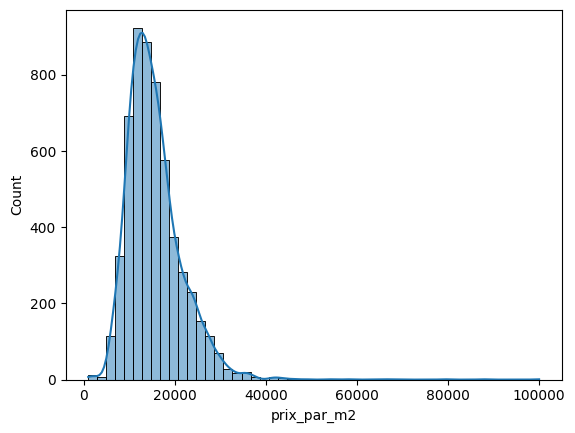

In [22]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['prix_par_m2'], bins=50, kde=True)

In [3]:
# suppression des vals aberrantes 

col = "prix_par_m2"
Q1 = df[col].quantile(0.10)
Q3 = df[col].quantile(0.90)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df[col] <= upper_bound]

<Axes: xlabel='prix_par_m2', ylabel='Count'>

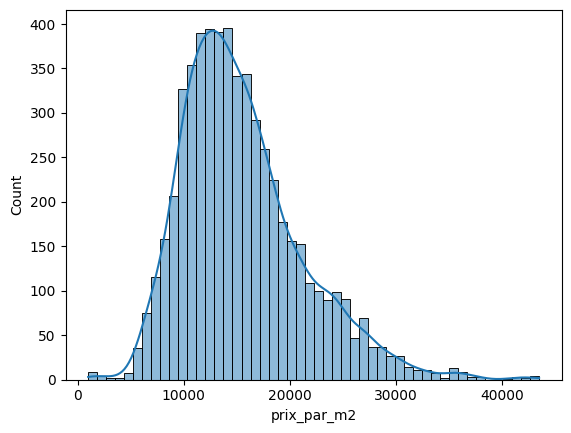

In [24]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['prix_par_m2'], bins=50, kde=True)

<Axes: xlabel='surface_m2', ylabel='Count'>

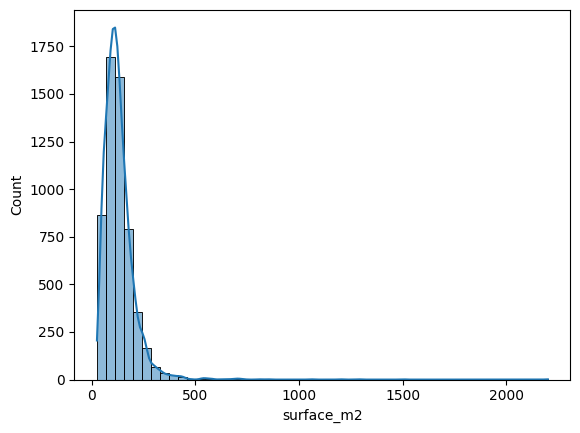

In [25]:
# distribution de surface m2 avec seaborn
import seaborn as sns
sns.histplot(df['surface_m2'], bins=50, kde=True)

In [4]:
# suppression des vals aberrantes 
col = "surface_m2"
Q1 = df[col].quantile(0.10)
Q3 = df[col].quantile(0.90)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df = df[df[col] <= upper_bound]

<Axes: xlabel='surface_m2', ylabel='Count'>

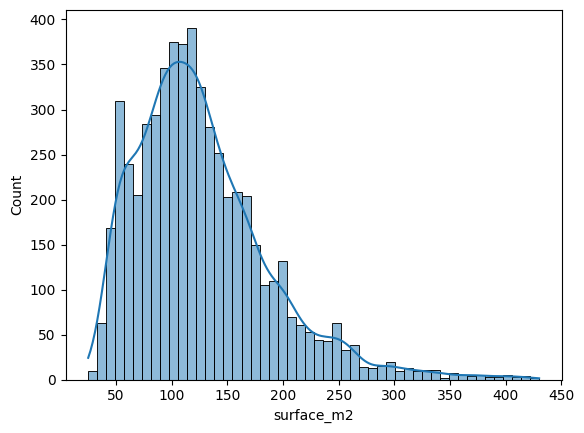

In [5]:
# distribution de surface m2 avec seaborn
import seaborn as sns
sns.histplot(df['surface_m2'], bins=50, kde=True)

In [10]:
df.isna().sum()

quartier             0
type_bien            0
surface_m2           0
prix_mad             0
chambres_total       6
salles_de_bain      27
etage_num         1581
etat_bien         1423
ascenseur            0
securite             0
parking_places       0
prix_par_m2          0
dtype: int64

In [6]:
# Médiane pour les variables numériques
df["salles_de_bain"] = df["salles_de_bain"].fillna(df["salles_de_bain"].median())
df["chambres_total"] = df["chambres_total"].fillna(df["chambres_total"].median())


In [29]:
df['etat_bien'].value_counts()

etat_bien
Bon état / habitable      2175
Correct                    774
Jamais habité / rénové     476
Neuf                       302
Refait à neuf              171
Travaux à prévoir          151
À rénover                  116
Bon                          1
Name: count, dtype: int64

In [7]:
# mapping des états de bien
mapping = {
    'Neuf': 'Neuf / Rénové',
    'Jamais habité / rénové': 'Neuf / Rénové',
    'Refait à neuf': 'Neuf / Rénové',
    'Bon état / habitable': 'Bon état',
    'Correct': 'Bon état',
    'Bon': 'Bon état',
    'À rénover': 'À rénover',
    'Travaux à prévoir': 'À rénover',
}

df['etat_bien'] = df['etat_bien'].map(mapping)

print(df['etat_bien'].value_counts(dropna=False))

etat_bien
Bon état         2950
NaN              1423
Neuf / Rénové     949
À rénover         267
Name: count, dtype: int64


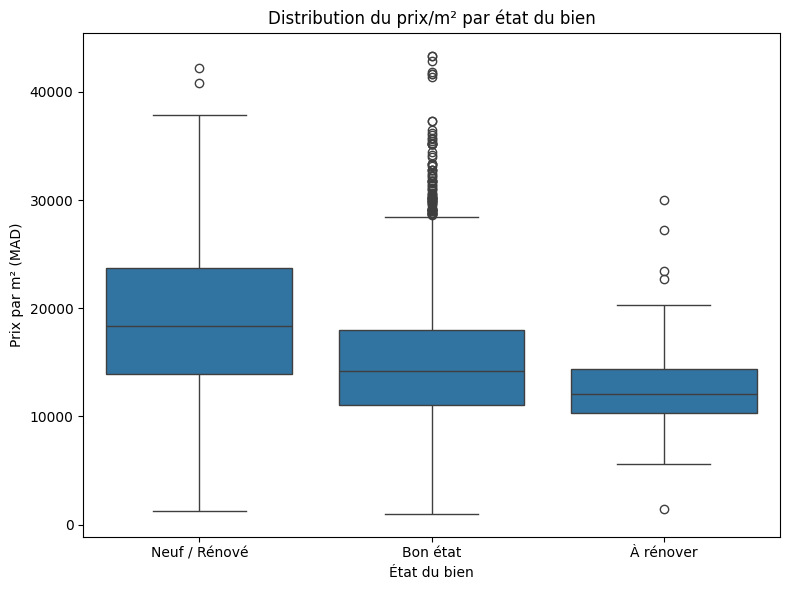

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

order = ['Neuf / Rénové', 'Bon état', 'À rénover']

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='etat_bien', y='prix_par_m2', order=order)
plt.ylabel('Prix par m² (MAD)')
plt.xlabel('État du bien')
plt.title('Distribution du prix/m² par état du bien')
plt.tight_layout()
plt.savefig('boxplot_etat_bien.png', dpi=150)
plt.show()

In [32]:
len(df['quartier'].value_counts())

63

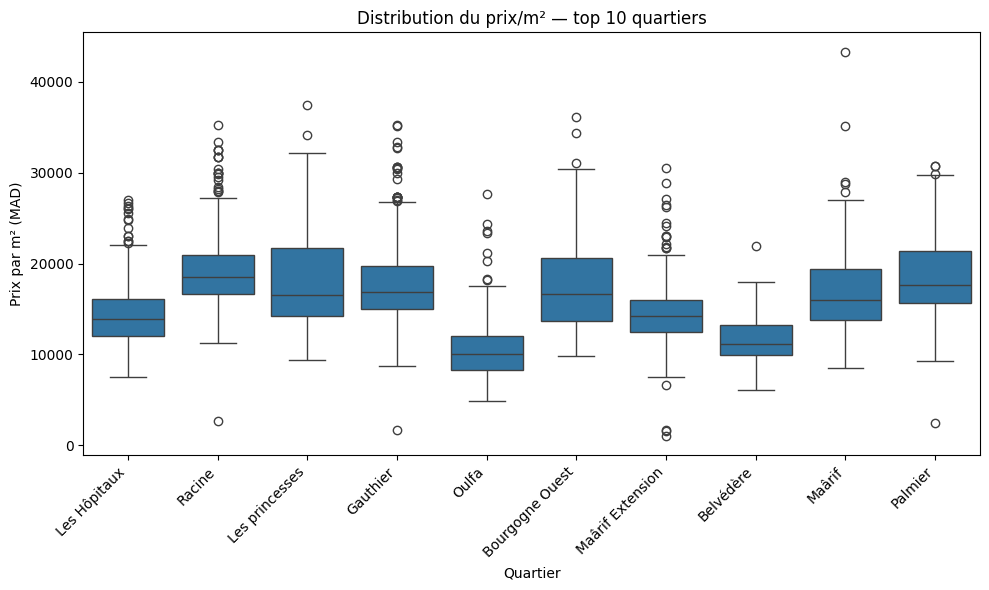

In [19]:
top10 = df['quartier'].value_counts().head(10).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['quartier'].isin(top10)], x='quartier', y='prix_par_m2', order=top10)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Prix par m² (MAD)')
plt.xlabel('Quartier')
plt.title('Distribution du prix/m² — top 10 quartiers')
plt.tight_layout()
plt.savefig('boxplot_quartier.png', dpi=150)
plt.show()

In [22]:
df.dtypes

quartier              str
type_bien             str
surface_m2          int64
prix_mad            int64
chambres_total    float64
salles_de_bain    float64
etage_num         float64
etat_bien             str
ascenseur           int64
securite            int64
parking_places      int64
prix_par_m2       float64
etat_bien_cat         str
dtype: object

# Modélisation — Estimation du prix au m²

In [33]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Colonnes catégorielles à encoder
cat_cols = ['quartier', 'type_bien', 'etat_bien']
num_cols = ['surface_m2', 'chambres_total', 'salles_de_bain', 'etage_num','ascenseur',
            'securite', 'parking_places']

X = df[cat_cols + num_cols].copy()
y = df['prix_par_m2']*0.9

# Encodage ordinal (compatible tree-based et linear avec get_dummies séparé)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
    stratify=df.loc[y.index, 'quartier']
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3912, 10), Test: (1677, 10)


In [34]:
import joblib

joblib.dump(enc, "models/ordinal_encoder_quartiers_apparts.pkl")

['models/ordinal_encoder_quartiers_apparts.pkl']

In [10]:
results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"{name:30s} | MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}")
    return model

## 1. Modèles linéaires

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lr  = evaluate("Linear Regression",
               Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
               X_train, y_train, X_test, y_test)

ridge = evaluate("Ridge (alpha=10)",
                 Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10))]),
                 X_train, y_train, X_test, y_test)

lasso = evaluate("Lasso (alpha=10)",
                 Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=10, max_iter=5000))]),
                 X_train, y_train, X_test, y_test)

Linear Regression              | MAE=3,143  RMSE=3,985  R²=0.3517
Ridge (alpha=10)               | MAE=3,142  RMSE=3,984  R²=0.3520
Lasso (alpha=10)               | MAE=3,141  RMSE=3,984  R²=0.3520


## 2. Decision Tree & Random Forest

In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = evaluate("Decision Tree",
              DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42),
              X_train, y_train, X_test, y_test)

rf = evaluate("Random Forest",
              RandomForestRegressor(n_estimators=300, max_depth=None,
                                    min_samples_leaf=5, n_jobs=-1, random_state=42),
              X_train, y_train, X_test, y_test)

Decision Tree                  | MAE=2,762  RMSE=3,787  R²=0.4542
Random Forest                  | MAE=2,249  RMSE=3,193  R²=0.6121


## 3. LightGBM

In [31]:
import lightgbm as lgb

lgbm = evaluate("LightGBM",
                lgb.LGBMRegressor(
                    n_estimators=1000,
                    learning_rate=0.05,
                    num_leaves=63,
                    min_child_samples=20,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=1.0,
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1
                ),
                X_train, y_train, X_test, y_test)

LightGBM                       | MAE=2,106  RMSE=2,911  R²=0.6776


## 4. CatBoost

In [11]:
from catboost import CatBoostRegressor

# CatBoost
X_cat = df[cat_cols + num_cols].copy()
# CatBoost n'accepte pas les NaN dans les colonnes catégorielles
for c in cat_cols:
    X_cat[c] = X_cat[c].fillna('Inconnu')
y_cat = df['prix_par_m2']*0.9

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42,
    stratify=df.loc[y_cat.index, 'quartier']
)

cat_indices = [X_cat.columns.get_loc(c) for c in cat_cols]

cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=0
)
cb.fit(X_train_cat, y_train_cat, cat_features=cat_indices)

pred_cb = cb.predict(X_test_cat)
mae_cb  = mean_absolute_error(y_test_cat, pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test_cat, pred_cb))
r2_cb   = r2_score(y_test_cat, pred_cb)
results['CatBoost'] = {'MAE': mae_cb, 'RMSE': rmse_cb, 'R²': r2_cb}
print(f"{'CatBoost':30s} | MAE={mae_cb:,.0f}  RMSE={rmse_cb:,.0f}  R²={r2_cb:.4f}")

CatBoost                       | MAE=1,959  RMSE=2,730  R²=0.7214


## 5. Validation croisée : CatBoost

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from catboost import Pool, CatBoostRegressor

X_cv = df[cat_cols + num_cols].copy()
# CatBoost n'accepte pas les NaN dans les colonnes catégorielles
for c in cat_cols:
    X_cv[c] = X_cv[c].fillna('Inconnu')

y_cv = df['prix_par_m2'] * 0.9
strat_groups = df['quartier'].values
quartier_encoded = LabelEncoder().fit_transform(strat_groups)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_maes, cv_rmses, cv_r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, quartier_encoded)):
    X_tr_f, X_val_f = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
    y_tr_f, y_val_f = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

    pool_tr  = Pool(X_tr_f,  y_tr_f,  cat_features=cat_cols)
    pool_val = Pool(X_val_f, y_val_f, cat_features=cat_cols)

    cb_cv = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=8,
        l2_leaf_reg=3, loss_function='RMSE', random_seed=42, verbose=0
    )
    cb_cv.fit(pool_tr, eval_set=pool_val, early_stopping_rounds=50)

    pred_val = cb_cv.predict(X_val_f)
    cv_maes.append(mean_absolute_error(y_val_f, pred_val))
    cv_rmses.append(np.sqrt(mean_squared_error(y_val_f, pred_val)))
    cv_r2s.append(r2_score(y_val_f, pred_val))
    print(f"  Fold {fold+1} | MAE={cv_maes[-1]:,.0f}  RMSE={cv_rmses[-1]:,.0f}  R²={cv_r2s[-1]:.4f}")

print(f"\n{'CV moyen':30s} | MAE={np.mean(cv_maes):,.0f} ± {np.std(cv_maes):,.0f}"
      f"  RMSE={np.mean(cv_rmses):,.0f} ± {np.std(cv_rmses):,.0f}"
      f"  R²={np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

  Fold 1 | MAE=1,915  RMSE=2,672  R²=0.7295
  Fold 2 | MAE=1,924  RMSE=2,735  R²=0.7203
  Fold 3 | MAE=1,979  RMSE=2,774  R²=0.7080
  Fold 4 | MAE=1,995  RMSE=2,847  R²=0.6648
  Fold 5 | MAE=1,973  RMSE=2,703  R²=0.7321

CV moyen                       | MAE=1,957 ± 32  RMSE=2,746 ± 60  R²=0.7109 ± 0.0246


## 6. Optimisation des hyperparamètres : Optuna + CatBoost

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations':       trial.suggest_int('iterations', 500, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':            trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':  trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count':     trial.suggest_int('border_count', 32, 255),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
    }

    fold_rmses = []
    for tr_idx, val_idx in skf.split(X_cv, quartier_encoded):
        X_tr_f, X_val_f = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
        y_tr_f, y_val_f = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr_f, y_tr_f, cat_features=cat_cols),
            eval_set=Pool(X_val_f, y_val_f, cat_features=cat_cols),
            early_stopping_rounds=50,
        )
        pred = model.predict(X_val_f)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_f, pred)))

    return np.mean(fold_rmses)

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nMeilleur RMSE CV : {study.best_value:,.0f}")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 19. Best value: 2731.43: 100%|██████████| 20/20 [35:29<00:00, 106.49s/it]


Meilleur RMSE CV : 2,731
Meilleurs hyperparamètres :
  iterations: 1505
  learning_rate: 0.12982472033726944
  depth: 5
  l2_leaf_reg: 1.7303685224475978
  bagging_temperature: 0.2671416984227821
  random_strength: 0.7603654527722213
  border_count: 178


In [23]:
# Ré-entraînement du meilleur modèle sur tout le train
best_params = study.best_params.copy()
best_params.update({'loss_function': 'RMSE', 'random_seed': 42, 'verbose': 0})

cb_best = CatBoostRegressor(**best_params)
cb_best.fit(
    Pool(X_train_cat, y_train_cat, cat_features=cat_cols),
    eval_set=Pool(X_test_cat, y_test_cat, cat_features=cat_cols),
    early_stopping_rounds=50,
)

pred_best = cb_best.predict(X_test_cat)
mae_best  = mean_absolute_error(y_test_cat, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_cat, pred_best))
r2_best   = r2_score(y_test_cat, pred_best)
results['CatBoost (Optuna)'] = {'MAE': mae_best, 'RMSE': rmse_best, 'R²': r2_best}
print(f"{'CatBoost (Optuna)':30s} | MAE={mae_best:,.0f}  RMSE={rmse_best:,.0f}  R²={r2_best:.4f}")

CatBoost (Optuna)              | MAE=1,973  RMSE=2,740  R²=0.7193


## 7. Interprétabilité SHAP de CatBoost optimisé

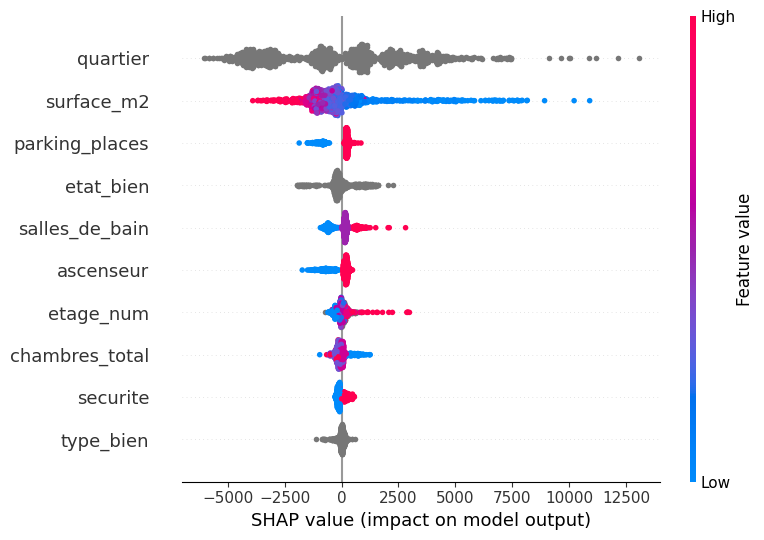

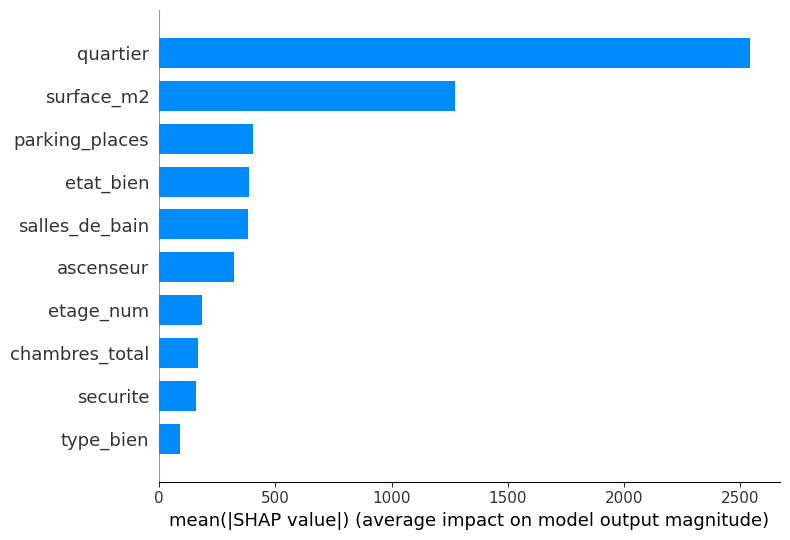

In [24]:
import shap

explainer = shap.TreeExplainer(cb_best)
shap_values = explainer.shap_values(Pool(X_test_cat, cat_features=cat_cols))

# Beeswarm — vue globale de l'impact de chaque feature
shap.summary_plot(shap_values, X_test_cat, plot_type='dot', show=True)

# Bar — importance SHAP moyenne absolue
shap.summary_plot(shap_values, X_test_cat, plot_type='bar', show=True)

## 8. Sauvegarde du modèle final

In [ ]:
import json, os

os.makedirs('models', exist_ok=True)

# Sauvegarde du modèle
cb_best.save_model('models/catboost_prix_m2_apparts.cbm')

# Métadonnées
meta = {
    'features': cat_cols + num_cols,
    'cat_features': cat_cols,
    'target': 'prix_m2',
    'test_metrics': {'MAE': round(mae_best, 2), 'RMSE': round(rmse_best, 2), 'R2': round(r2_best, 4)},
    'best_params': study.best_params,
}
with open('models/catboost_prix_m2_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Modèle sauvegardé        : models/catboost_prix_m2_apparts.cbm")
print("Métadonnées sauvegardées : models/catboost_prix_m2_apparts_meta.json")
print(f"\nPerformances finales — CatBoost (Optuna)")
print(f"  MAE  : {mae_best:,.0f} MAD/m²")
print(f"  RMSE : {rmse_best:,.0f} MAD/m²")
print(f"  R²   : {r2_best:.4f}")

Modèle sauvegardé        : models/catboost_prix_m2.cbm
Métadonnées sauvegardées : models/catboost_prix_m2_meta.json

Performances finales — CatBoost (Optuna)
  MAE  : 1,973 MAD/m²
  RMSE : 2,740 MAD/m²
  R²   : 0.7193
